# Step 1: Install And Import Python Libraries

The first step is to install and import Python libraries.
We need to install the `vaderSentiment` package for VADER and the`flair` package for flair.

In [2]:
# Install vaderSentiment package for VADER
!pip install vaderSentiment


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Install flair
!pip install flair

  Using cached flair-0.15.1-py3-none-any.whl (1.2 MB)
     ------------------------------------ 140.5/140.5 kB 757.5 kB/s eta 0:00:00
  Using cached conllu-4.5.3-py2.py3-none-any.whl (16 kB)
  Using cached deprecated-1.3.1-py2.py3-none-any.whl (11 kB)
  Using cached ftfy-6.3.1-py3-none-any.whl (44 kB)
  Using cached huggingface_hub-1.17.0-py3-none-any.whl (671 kB)
  Using cached langdetect-1.0.9.tar.gz (981 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached lxml-6.1.1-cp311-cp311-win_amd64.whl (4.0 MB)
  Using cached matplotlib-3.10.9-cp311-cp311-win_amd64.whl (8.2 MB)
  Using cached more_itertools-11.1.0-py3-none-any.whl (72 kB)
  Using cached mpld3-0.5.12-py3-none-any.whl (203 kB)
  Using cached pptree-3.1.tar.gz (3.0 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached pytorch_revgrad-0.2.0-py3-none-any.whl (4.6 kB)
  Using cached regex-2026.5.9-c

  DEPRECATION: sqlitedict is being installed using the legacy 'setup.py install' method, because it does not have a 'pyproject.toml' and the 'wheel' package is not installed. pip 23.1 will enforce this behaviour change. A possible replacement is to enable the '--use-pep517' option. Discussion can be found at https://github.com/pypa/pip/issues/8559
  DEPRECATION: pptree is being installed using the legacy 'setup.py install' method, because it does not have a 'pyproject.toml' and the 'wheel' package is not installed. pip 23.1 will enforce this behaviour change. A possible replacement is to enable the '--use-pep517' option. Discussion can be found at https://github.com/pypa/pip/issues/8559
  DEPRECATION: docopt is being installed using the legacy 'setup.py install' method, because it does not have a 'pyproject.toml' and the 'wheel' package is not installed. pip 23.1 will enforce this behaviour change. A possible replacement is to enable the '--use-pep517' option. Discussion can be found a

In [4]:
!pip install textblob

  Using cached textblob-0.20.0-py3-none-any.whl (624 kB)
  Using cached nltk-3.9.4-py3-none-any.whl (1.6 MB)



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


After installing the packages, let's import the Python libraries. We need to import `pandas` and `numpy` for data processing.

For the sentiment analysis, we need to import `TextBlob`, `SentimentIntensityAnalyzer` from `vaderSentiment`, and `TextClassifier` from `flair`. We also need to load the English sentiment data from `TextClassifier` and import `Sentence` for text processing for the flair pre-trained model.

To check the sentiment prediction accuracy, we need to import `accuracy_score` from `sklearn`.

Last but not least, we set the `pandas` dataframe column width to be 1000, which will allow us to see more content from the review.

In [7]:
!pip install --upgrade numpy pandas

  Using cached pandas-3.0.3-cp311-cp311-win_amd64.whl (9.9 MB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl (349 kB)



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# Import the necessary libraries/packages
# Data processing
import pandas as pd
import numpy as np

# Import TextBlob
from textblob import TextBlob
from textblob import Blobber
from textblob.sentiments import NaiveBayesAnalyzer

# Import VADER sentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Import flair pre-trained sentiment model
from flair.models import TextClassifier
classifier = TextClassifier.load('en-sentiment')

# Import flair Sentence to process input text
from flair.data import Sentence

# Import accuracy_score to check performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Set a wider colwith
pd.set_option('display.max_colwidth', 1000)

c:\Users\jesse\OneDrive - LYCEE Jules Haag\Formation-Dev-IA\Mes projets\NLP\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Step 2: Download And Read Data

The second step is to download and read in the dataset.

The UCI Machine Learning Repository has the review data from three websites: imdb.com, amazon.com, and yelp.com. We will use the review data from amazon.com for this tutorial. Please follow these steps to download the data.
1. Go to: https://archive.ics.uci.edu/ml/datasets/Sentiment+Labelled+Sentences
2. Click "Data Folder"
3. Download "sentiment labeled sentences.zip"
4. Unzip "sentiment labeled sentences.zip"
5. Copy the file "amazon_cells_labelled.txt" to your project folder


Those who are using Google Colab for this analysis need to mount Google Drive to read the dataset. You can ignore the code below if you are not using Google Colab.

In [ ]:
# # Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# # Change directory
# import os
# os.chdir("/content/drive/MyDrive/GRETA/NLP Week 7 - How to train a model in NLP/")

# # Print out the current directory
# !pwd

ModuleNotFoundError: No module named 'google.colab'

Now let's read the data into a `pandas` dataframe and see what the dataset looks like.

In [15]:
import pandas as pd
import requests
import zipfile
import io

# URL officielle du package "Sentiment Labelled Sentences" de l'UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00331/sentiment%20labelled%20sentences.zip"

print("Téléchargement du dataset...")
response = requests.get(url)

# Extraction et lecture du fichier imdb_labelled.txt
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    # Le fichier est dans un sous-dossier du ZIP
    file_path = "sentiment labelled sentences/imdb_labelled.txt"
    
    with z.open(file_path) as f:
        # Le fichier utilise des tabulations (\t) comme séparateur et n'a pas de colonnes de titre
        amz_review = pd.read_csv(f, sep="\t", header=None, names=["review", "label"])

print(f"Extraction réussie ! Nombre de lignes : {len(amz_review)}")
print("\nAperçu des données :")
print(amz_review.head())

Téléchargement du dataset...
Extraction réussie ! Nombre de lignes : 748

Aperçu des données :
                                                                                                                                                                                         review  \
0                                                                                                       A very, very, very slow-moving, aimless movie about a distressed, drifting young man.     
1                                                                                           Not sure who was more lost - the flat characters or the audience, nearly half of whom walked out.     
2  Attempting artiness with black & white and clever camera angles, the movie disappointed - became even more ridiculous - as the acting was poor and the plot and lines almost non-existent.     
3                                                                                                                            

In [16]:
# Read in data
# amz_review = pd.read_csv('datasets/amazon_cells_labelled.txt', sep='\t', names=['review', 'label'])

# # Take a look at the data
# amz_review.head()

In [17]:
# Get the dataset information
amz_review.info()

<class 'pandas.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  748 non-null    str  
 1   label   748 non-null    int64
dtypes: int64(1), str(1)
memory usage: 11.8 KB


`.info` helps us to get the information about the dataset.

From the output, we can see that this data set has two columns, 1000 records, and no missing data. The 'review' column is `object` type, and the 'label'column is `int64` type.

Next, let's check the distribution of the label. There are 500 positive and 500 negative reviews in the dataset, so we have a balanced dataset. For a balanced dataset, we can use accuracy as the performance metric.

In [18]:
# Check the label distribution
amz_review['label'].value_counts()

label
1    386
0    362
Name: count, dtype: int64

# What is TextBlob?

TextBlob is a Python library for Natural Language Processing (NLP). Sentiment analysis is one of many NLP tasks that TextBlob supports.


TextBlob offers two primary methods for sentiment analysis: the Pattern Analyzer and the Naive Bayes Analyzer. Each method uses a different approach to analyze the sentiment of text.

* **Pattern Analyzer:** This is the default analyzer in TextBlob. It's based on the pattern library and uses a lexicon (a list of known words with their associated sentiment scores). The sentiment score is a tuple representing polarity and subjectivity.

> The sentiment property in TextBlob by default using the Pattern Anlyzer. It returns a polarity score and a subjectivity score for the input text.
> * The polarity score ranges from -1 to 1, where -1 means extremely negative, and 1 means highly positive. A score near 0 means neutral sentiment.
> * The subjectivity score ranges from 0 to 1, where 0 means extremely objective and 1 means highly subjective.


* **Naive Bayes Analyzer:** This uses a Naive Bayes classifier trained on a dataset of movie reviews. It's more context-aware compared to the lexicon-based Pattern Analyzer. This analyzer classifies text into either 'pos' or 'neg' categories, providing a probabilistic sentiment classification.

In [19]:
!python -m textblob.download_corpora
# to executes the TextBlob module's script to download necessary data,
# including datasets and corpora used for tasks like part-of-speech tagging, noun phrase extraction, and sentiment analysis.

Finished.


[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\jesse\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\jesse\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jesse\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\jesse\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to
[nltk_data]     C:\Users\jesse\AppData\Roaming\nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\jesse\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is alr

In [20]:
from textblob.sentiments import NaiveBayesAnalyzer

# Example text
text = "I love this product, it's absolutely wonderful!"

# Using Pattern Analyzer
blob_pattern = TextBlob(text)
print("Pattern Analyzer Sentiment:")
print("Polarity:", blob_pattern.sentiment.polarity)
print("Subjectivity:", blob_pattern.sentiment.subjectivity)

# Using Naive Bayes Analyzer
blob_naivebayes = TextBlob(text, analyzer=NaiveBayesAnalyzer())
print("\nNaive Bayes Analyzer Sentiment:")
print("Classification:", blob_naivebayes.sentiment.classification)
print("Positive Probability:", blob_naivebayes.sentiment.p_pos)
print("Negative Probability:", blob_naivebayes.sentiment.p_neg)

Pattern Analyzer Sentiment:
Polarity: 0.75
Subjectivity: 0.8

Naive Bayes Analyzer Sentiment:
Classification: pos
Positive Probability: 0.6560203571571461
Negative Probability: 0.34397964284285404


Let's take a peek on the TextBlob's Lexicon in Pattern Analyzer method.

In [21]:
# List of words to check
words = ["happy", "sad", "neutral", "exciting", "frustrating","crazy","yummy", ":D", "}:("]

# Checking the sentiment of each word
for word in words:
    blob = TextBlob(word)
    print(f"Word: {word}, Sentiment: {blob.sentiment}")


Word: happy, Sentiment: Sentiment(polarity=0.8, subjectivity=1.0)
Word: sad, Sentiment: Sentiment(polarity=-0.5, subjectivity=1.0)
Word: neutral, Sentiment: Sentiment(polarity=0.0, subjectivity=0.0)
Word: exciting, Sentiment: Sentiment(polarity=0.3, subjectivity=0.8)
Word: frustrating, Sentiment: Sentiment(polarity=-0.4, subjectivity=0.9)
Word: crazy, Sentiment: Sentiment(polarity=-0.6, subjectivity=0.9)
Word: yummy, Sentiment: Sentiment(polarity=0.0, subjectivity=0.0)
Word: :D, Sentiment: Sentiment(polarity=1.0, subjectivity=1.0)
Word: }:(, Sentiment: Sentiment(polarity=-0.75, subjectivity=1.0)


In [22]:
# Example text
text = 'It is an interesting movie.'

# TextBlob sentiment
textBlob_sentiment = TextBlob(text).sentiment
textBlob_sentiment

Sentiment(polarity=0.5, subjectivity=0.5)

In [23]:
# Example text
text = 'It is a very interesting movie.'

# TextBlob sentiment
textBlob_sentiment = TextBlob(text).sentiment
textBlob_sentiment

Sentiment(polarity=0.65, subjectivity=0.65)

In this example, the sample text has a polarity score of 0.65 and the subjectivity score of 0.65, which means TextBlob interprets the sentence to have a subjective positive sentiment.

We can use `.polarity` to extract the sentiment score.

In [24]:
# Extract sentiment score
textBlob_sentiment.polarity

0.65

Let's test using other examples

In [25]:
text2 = "This movie is not interesting."

# TextBlob sentiment
textBlob_sentiment2 = TextBlob(text2).sentiment
textBlob_sentiment2

Sentiment(polarity=-0.25, subjectivity=0.5)

In [26]:
# Extract sentiment score
textBlob_sentiment2.polarity

-0.25

In [27]:
# TextBlob sentiment using Naive Bayes Analyzer
blob_naivebayes = TextBlob(text2, analyzer=NaiveBayesAnalyzer())
print("Classification:", blob_naivebayes.sentiment.classification)
print("Positive Probability:", blob_naivebayes.sentiment.p_pos)
print("Negative Probability:", blob_naivebayes.sentiment.p_neg)

Classification: neg
Positive Probability: 0.4540202655486483
Negative Probability: 0.5459797344513515


In [28]:
text3 = "I cannot say that this movie is interesting."

# TextBlob sentiment
textBlob_sentiment3 = TextBlob(text3).sentiment
textBlob_sentiment3

Sentiment(polarity=0.5, subjectivity=0.5)

In [29]:
# Extract sentiment score
textBlob_sentiment2.polarity

-0.25

In [30]:
# TextBlob sentiment using Naive Bayes Analyzer
blob_naivebayes = TextBlob(text3, analyzer=NaiveBayesAnalyzer())
print("Classification:", blob_naivebayes.sentiment.classification)
print("Positive Probability:", blob_naivebayes.sentiment.p_pos)
print("Negative Probability:", blob_naivebayes.sentiment.p_neg)

Classification: neg
Positive Probability: 0.4468402964070675
Negative Probability: 0.5531597035929323


# What is VADER?

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a Python library focusing on social media sentiments. It has a built-in algorithm to change sentiment intensity based on punctuations, slang, emojis, and acronyms.

The output of VADER includes four scores: compound score, negative score, neutral score, and positive score.

* The pos, neu, and neg represent the percentage of tokens that fall into each category, so they add up together to be 100%.
* The compound score is a single score to measure the sentiment of the text. Similar to TextBlob, it ranges from -1 (extremely negative) to 1 (extremely positive). The scores near 0 represent the neural sentiment score.
* The compound score is not a simple aggregation of the pos, neu, and neg scores. Instead, it incorporates rule-based enhancements such as punctuation amplifiers.

In [31]:
# Take a peek on VADER's lexicon
import nltk

# Download VADER lexicon
nltk.download('vader_lexicon')

# Import the SentimentIntensityAnalyzer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Create an instance of SentimentIntensityAnalyzer
sid = SentimentIntensityAnalyzer()

# Accessing the lexicon (a dictionary of words and their sentiment scores)
vader_lexicon = sid.lexicon

# Displaying a portion of the lexicon
for word in list(vader_lexicon.keys())[-30:]:  # Display last 30 words for brevity
    print(f"{word}: {vader_lexicon[word]}")


wrong: -2.1
wronged: -1.9
yay: 2.4
yeah: 1.2
yearning: 0.5
yeees: 1.7
yep: 1.2
yes: 1.7
youthful: 1.3
yucky: -1.8
yummy: 2.4
zealot: -1.9
zealots: -0.8
zealous: 0.5
{:: 1.8
|-0: -1.2
|-:: -0.8
|-:>: -1.6
|-o: -1.2
|:: -0.5
|;-): 2.2
|=: -0.4
|^:: -1.1
|o:: -0.9
||-:: -2.3
}:: -2.1
}:(: -2.0
}:): 0.4
}:-(: -2.1
}:-): 0.3


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\jesse\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [32]:
# Let's test using blank text
text = ""

# VADER Sentiment
vader = SentimentIntensityAnalyzer()
vader_sentiment = vader.polarity_scores(text)
vader_sentiment

{'neg': 0.0, 'neu': 0.0, 'pos': 0.0, 'compound': 0.0}

With an absent of any semantic tokens or punctuation, VADER assigns a completely neutral score or zero

In [33]:
# Example text
text = 'It is an interesting movie.'

# VADER Sentiment
vader = SentimentIntensityAnalyzer()
vader_sentiment = vader.polarity_scores(text)
vader_sentiment

{'neg': 0.0, 'neu': 0.597, 'pos': 0.403, 'compound': 0.4019}

In [34]:
# Extract sentiment score
vader_sentiment['compound']

0.4019

In [35]:
# Example text
text = 'It is a very interesting movie.'

# VADER Sentiment
vader = SentimentIntensityAnalyzer()
vader_sentiment = vader.polarity_scores(text)
vader_sentiment

{'neg': 0.0, 'neu': 0.572, 'pos': 0.428, 'compound': 0.4576}

VADER gave the sample text compound score of 0.46. There is no negative word in the sentence, so the neg score value is 0. There are 63% of neutral words and 37.4% of positive words in the sentence.

The output of VADER is saved as a dictionary. We can extract the compound sentiment score by the key 'compound'.

In [36]:
# Extract sentiment score
vader_sentiment['compound']

0.4576

Let's test using other examples

In [37]:
text2 = "This movie is not interesting."
vader_sentiment2 = vader.polarity_scores(text2)
vader_sentiment2

{'neg': 0.361, 'neu': 0.639, 'pos': 0.0, 'compound': -0.3089}

In [38]:
# Extract sentiment score
vader_sentiment2['compound']

-0.3089

In [39]:
text3 = "I cannot say that this movie is interesting."
vader_sentiment3 = vader.polarity_scores(text3)
vader_sentiment3

{'neg': 0.0, 'neu': 0.69, 'pos': 0.31, 'compound': 0.4019}

# What is Flair

Flair is a state-of-art NLP framework built on PyTorch. It incorporates recent researches and provides an easy way to combine different embeddings to various NLP tasks. The pre-trained sentiment model offers a tool for sentiment analysis without training a customized model.

Unlike TextBlob and VADER that output a sentiment score between -1 and 1, flair sentiment output the predicted label with a confidence score. The confidence score ranges from 0 to 1, with 1 being very confident and 0 being very unconfident.

Before predicting the sentiment of a text, the input text needs to be tokenized by `Sentence()`. After that, we can see the sample text was split into nine tokens.

In [40]:
# Example text
text = 'It is an interesting movie.'

# Flair tokenization
sentence = Sentence(text)
sentence

Sentence[6]: "It is an interesting movie."

Next, we use `.predict` to predict the sentiment.

In [41]:
# Flair sentiment prediction
classifier.predict(sentence)
sentence

Sentence[6]: "It is an interesting movie." → POSITIVE (0.9853)

In [42]:
# Example text
text = 'It is a very interesting movie.'

# Flair tokenization
sentence = Sentence(text)
sentence

Sentence[7]: "It is a very interesting movie."

In [43]:
# Flair sentiment prediction
classifier.predict(sentence)
sentence

Sentence[7]: "It is a very interesting movie." → POSITIVE (0.9958)

The sample text has the predicted sentiment of POSITIVE and the confidence score of 0.9958. Since 0.9958 is close to 1, flair is very confident about the predictions.

The predicted label is saved as value and the prediction confidence is saved as score. We can use `sentence.labels[0].value` and `sentence.labels[0].score` separately to extract the values.

In [44]:
# Extract sentiment prediction score
print(f'Flair classified the review as {sentence.labels[0].value} with the score of {sentence.labels[0].score:.2f}')

Flair classified the review as POSITIVE with the score of 1.00


Let's test using other examples

In [45]:
# Example text
text2 = 'This movie is not interesting.'

# Flair tokenization
sentence2 = Sentence(text2)
sentence2

Sentence[6]: "This movie is not interesting."

In [46]:
# Flair sentiment prediction
classifier.predict(sentence2)
sentence2

Sentence[6]: "This movie is not interesting." → NEGATIVE (0.9999)

In [47]:
# Extract sentiment prediction score
print(f'Flair classified the review as {sentence2.labels[0].value} with the score of {sentence2.labels[0].score:.2f}')

Flair classified the review as NEGATIVE with the score of 1.00


In [48]:
# Example text
text3 = 'I cannot say that this movie is interesting.'

# Flair tokenization
sentence3 = Sentence(text3)
sentence3

Sentence[9]: "I cannot say that this movie is interesting."

In [49]:
# Flair sentiment prediction
classifier.predict(sentence3)
sentence3

Sentence[9]: "I cannot say that this movie is interesting." → POSITIVE (0.7052)

In [50]:
# Extract sentiment prediction score
print(f'Flair classified the review as {sentence3.labels[0].value} with the score of {sentence3.labels[0].score:.2f}')

Flair classified the review as POSITIVE with the score of 0.71


# How To Use TextBlob For Sentiment Analysis

We will apply TextBlob to the Amazon review dataset and see how it performs.

We first get the sentiment polarity for each review and save the values into a column called 'scores_TextBlob'. Then check if the polarity score is positive. If the score is greater than or equal to zero, the predicted sentiment for the review is positive (labeled as 1). Otherwise, the predicted sentiment for the review is negative (labeled as 0).

In [51]:
# Get sentiment score for each review
amz_review['scores_TextBlob'] = amz_review['review'].apply(lambda s: TextBlob(s).sentiment.polarity)

# Predict sentiment label for each review
amz_review['pred_TextBlob'] = amz_review['scores_TextBlob'].apply(lambda x: 1 if x >=0 else 0)
amz_review.head()

,review,label,scores_TextBlob,pred_TextBlob
0,"A very, very, very slow-moving, aimless movie about a distressed, drifting young man.",0,0.180000,1
1,"Not sure who was more lost - the flat characters or the audience, nearly half of whom walked out.",0,0.014583,1
2,"Attempting artiness with black & white and clever camera angles, the movie disappointed - became even more ridiculous - as the acting was poor and the plot and lines almost non-existent.",0,-0.122917,0
3,Very little music or anything to speak of.,0,-0.243750,0
4,The best scene in the movie was when Gerardo is trying to find a song that keeps running through his head.,1,1.000000,1


After getting predictions from TextBlob, let's check the prediction accuracy.

In [52]:
# Compare Actual and Predicted and get the Accuracy, Precision, Recall, and F1 score
actual_labels = amz_review['label']
predicted_labels = amz_review['pred_TextBlob']

accuracy_TextBlob = accuracy_score(actual_labels,predicted_labels)
precision_TextBlob = precision_score(actual_labels, predicted_labels, average='macro')  # Use 'micro' or 'weighted' if more appropriate
recall_TextBlob = recall_score(actual_labels, predicted_labels, average='macro')
f1_TextBlob = f1_score(actual_labels, predicted_labels, average='macro')

print(f'Accuracy:', accuracy_TextBlob)
print(f'Precision:', precision_TextBlob)
print(f'Recall:', recall_TextBlob)
print(f'F1:', f1_TextBlob)

Accuracy: 0.7486631016042781
Precision: 0.7810017213983051
Recall: 0.7429937308562105
F1: 0.7381323044148647


Comparing the actual label with the TextBlob prediction, we get an accuracy score of 0.688, which means that TextBlob predicted the review sentiment 68.8% of the time.

## Use Naive Bayes classifier

In [53]:
# Function to apply Naive Bayes Sentiment Analysis
def naive_bayes_sentiment(text):
    blob = TextBlob(text, analyzer=NaiveBayesAnalyzer())
    return blob.sentiment.classification

# # Applying the Naive Bayes classifier to get sentiment
# amz_review['naive_bayes_analysis'] = amz_review['review'].apply(naive_bayes_sentiment)

# # Predict sentiment label (1 for positive, 0 for negative)
# amz_review['pred_TextBlob_NaiveBayes'] = amz_review['naive_bayes_analysis'].apply(lambda x: 1 if x.classification == 'pos' else 0)
# amz_review.head()

# Slice the DataFrame to process only the top 100 rows (only for example in this coding practice)
amz_review_top100 = amz_review.head(100).copy()

# Applying the Naive Bayes classifier to get sentiment for the top 30 rows
amz_review_top100['naive_bayes_analysis'] = amz_review_top100['review'].apply(naive_bayes_sentiment)

# Predict sentiment label (1 for positive, 0 for negative)
amz_review_top100['pred_TextBlob_NaiveBayes'] = amz_review_top100['naive_bayes_analysis'].apply(lambda x: 1 if x == 'pos' else 0)

# Display the first few rows of the processed DataFrame
amz_review_top100.head()

,review,label,scores_TextBlob,pred_TextBlob,naive_bayes_analysis,pred_TextBlob_NaiveBayes
0,"A very, very, very slow-moving, aimless movie about a distressed, drifting young man.",0,0.180000,1,neg,0
1,"Not sure who was more lost - the flat characters or the audience, nearly half of whom walked out.",0,0.014583,1,neg,0
2,"Attempting artiness with black & white and clever camera angles, the movie disappointed - became even more ridiculous - as the acting was poor and the plot and lines almost non-existent.",0,-0.122917,0,neg,0
3,Very little music or anything to speak of.,0,-0.243750,0,pos,1
4,The best scene in the movie was when Gerardo is trying to find a song that keeps running through his head.,1,1.000000,1,pos,1


Calculating the Accurancy, Precision, Recall, and F1 score from the result of TextBlob - Naive Bayes

In [54]:
# Compare Actual and Predicted and get the Accuracy, Precision, Recall, and F1 score
# actual_labels = amz_review['label']
# predicted_labels = amz_review['pred_TextBlob_NaiveBayes']

# Compare Actual and Predicted and get the Accuracy, Precision, Recall, and F1 score for the top 100 data
actual_labels = amz_review_top100['label']
predicted_labels = amz_review_top100['pred_TextBlob_NaiveBayes']

accuracy_TextBlob_NB = accuracy_score(actual_labels,predicted_labels)
precision_TextBlob_NB = precision_score(actual_labels, predicted_labels, average='macro')  # Use 'micro' or 'weighted' if more appropriate
recall_TextBlob_NB = recall_score(actual_labels, predicted_labels, average='macro')
f1_TextBlob_NB = f1_score(actual_labels, predicted_labels, average='macro')

print(f'Accuracy:', accuracy_TextBlob_NB)
print(f'Precision:', precision_TextBlob_NB)
print(f'Recall:', recall_TextBlob_NB)
print(f'F1:', f1_TextBlob_NB)

Accuracy: 0.78
Precision: 0.7836538461538461
Recall: 0.7906403940886699
F1: 0.779205138498595


# How To Use VADER For Sentiment Analysis

We will apply VADER to the Amazon review dataset and see how it performs.

We first get the sentiment compound score for each review and save the values into a column called 'scores_VADER'. Then check if the compound score is positive. If the score is greater than or equal to zero, the predicted sentiment for the review is positive (labeled as 1). Otherwise, the predicted sentiment for the review is negative (labeled as 0).

In [55]:
# Get sentiment score for each review
vader_sentiment = SentimentIntensityAnalyzer()
amz_review['scores_VADER'] = amz_review['review'].apply(lambda s: vader_sentiment.polarity_scores(s)['compound'])

# Predict sentiment label for each review
amz_review['pred_VADER'] = amz_review['scores_VADER'].apply(lambda x: 1 if x >=0 else 0)
amz_review.head()

,review,label,scores_TextBlob,pred_TextBlob,scores_VADER,pred_VADER
0,"A very, very, very slow-moving, aimless movie about a distressed, drifting young man.",0,0.180000,1,-0.4215,0
1,"Not sure who was more lost - the flat characters or the audience, nearly half of whom walked out.",0,0.014583,1,-0.5507,0
2,"Attempting artiness with black & white and clever camera angles, the movie disappointed - became even more ridiculous - as the acting was poor and the plot and lines almost non-existent.",0,-0.122917,0,-0.7178,0
3,Very little music or anything to speak of.,0,-0.243750,0,0.0000,1
4,The best scene in the movie was when Gerardo is trying to find a song that keeps running through his head.,1,1.000000,1,0.6369,1


After getting predictions from VADER, let's check the prediction accuracy.

In [56]:
# Compare Actual and Predicted and get the Accuracy, Precision, Recall, and F1 score
actual_labels = amz_review['label']
predicted_labels = amz_review['pred_VADER']

accuracy_VADER = accuracy_score(actual_labels,predicted_labels)
precision_VADER = precision_score(actual_labels, predicted_labels, average='macro')  # Use 'micro' or 'weighted' if more appropriate
recall_VADER = recall_score(actual_labels, predicted_labels, average='macro')
f1_VADER = f1_score(actual_labels, predicted_labels, average='macro')

print(f'Accuracy:', accuracy_VADER)
print(f'Precision:', precision_VADER)
print(f'Recall:', recall_VADER)
print(f'F1:', f1_VADER)

Accuracy: 0.7754010695187166
Precision: 0.7992089859199494
Recall: 0.7707039189305241
F1: 0.768625718073354


Comparing the actual label with the VADER prediction, we get an accuracy score of 0.768, which means that VADER predicted the review sentiment 76.8% of the time.

TextBlob has a prediction accuracy of 68.8% for the same dataset, so VADER has an 8% improvement over the TextBlob prediction.

# How To Use Flair For Sentiment Analysis

We will apply the flair pre-trained sentiment model to predict the sentiment of the Amazon reviews.

Firstly, let's define a function that takes a review as input and the predicted label and confidence as outputs.

In [57]:
# Define a function to get Flair sentiment prediction score
def score_flair(text):
  sentence = Sentence(text)
  classifier.predict(sentence)
  score = sentence.labels[0].score
  value = sentence.labels[0].value
  return score, value

Then apply the function to each review in the dataset.

In [58]:
# Get sentiment score for each review
amz_review['scores_flair'] = amz_review['review'].apply(lambda s: score_flair(s)[0])

# Predict sentiment label for each review
amz_review['pred_flair'] = amz_review['review'].apply(lambda s: score_flair(s)[1])

In [59]:
amz_review.head()

,review,label,scores_TextBlob,pred_TextBlob,scores_VADER,pred_VADER,scores_flair,pred_flair
0,"A very, very, very slow-moving, aimless movie about a distressed, drifting young man.",0,0.180000,1,-0.4215,0,0.999720,NEGATIVE
1,"Not sure who was more lost - the flat characters or the audience, nearly half of whom walked out.",0,0.014583,1,-0.5507,0,0.999814,NEGATIVE
2,"Attempting artiness with black & white and clever camera angles, the movie disappointed - became even more ridiculous - as the acting was poor and the plot and lines almost non-existent.",0,-0.122917,0,-0.7178,0,0.999977,NEGATIVE
3,Very little music or anything to speak of.,0,-0.243750,0,0.0000,1,0.999937,NEGATIVE
4,The best scene in the movie was when Gerardo is trying to find a song that keeps running through his head.,1,1.000000,1,0.6369,1,0.986026,NEGATIVE


In [60]:
# Check the distribution of the score
amz_review['scores_flair'].describe()

count    748.000000
mean       0.977585
std        0.070822
min        0.506444
25%        0.995053
50%        0.999277
75%        0.999865
max        0.999998
Name: scores_flair, dtype: float64

We can see that the summary statistics show that most flair scores are close to 1, which means that the flair sentiment model is overall very confident about the predictions.

In [61]:
# Check the counts of labels
amz_review['pred_flair'].value_counts()

pred_flair
NEGATIVE    377
POSITIVE    371
Name: count, dtype: int64

The distribution of the labels is very balanced.

Before checking the prediction accuracy etc, we need to map the 'NEGATIVE' value to 0 and the 'POSITIVE' value to 1 because the Amazon review dataset has true labels of 0 and 1.



In [62]:
# Change the label of flair prediction to 0 if negative and 1 if positive
mapping = {'NEGATIVE': 0, 'POSITIVE': 1}
amz_review['pred_flair'] = amz_review['pred_flair'].map(mapping)

In [63]:
# Check counts
amz_review['pred_flair'].value_counts()

pred_flair
0    377
1    371
Name: count, dtype: int64

In [64]:
# Compare Actual and Predicted and get the Accuracy, Precision, Recall, and F1 score
actual_labels = amz_review['label']
predicted_labels = amz_review['pred_flair']

accuracy_flair = accuracy_score(actual_labels,predicted_labels)
precision_flair = precision_score(actual_labels, predicted_labels, average='macro')  # Use 'micro' or 'weighted' if more appropriate
recall_flair = recall_score(actual_labels, predicted_labels, average='macro')
f1_flair = f1_score(actual_labels, predicted_labels, average='macro')

print(f'Accuracy:', accuracy_flair)
print(f'Precision:', precision_flair)
print(f'Recall:', recall_flair)
print(f'F1:', f1_flair)

Accuracy: 0.9398395721925134
Precision: 0.9399965681683313
Recall: 0.9404216643288581
F1: 0.9398308614411635


After comparing the flair prediction with the actual sentiment label, we can see that flair predicts the sentiment correctly 94.8% of the time! The prediction accuracy is an 18% increase from VADER and a 26% increase from TextBlob!

# Visualization

In [65]:
!pip install matplotlib


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


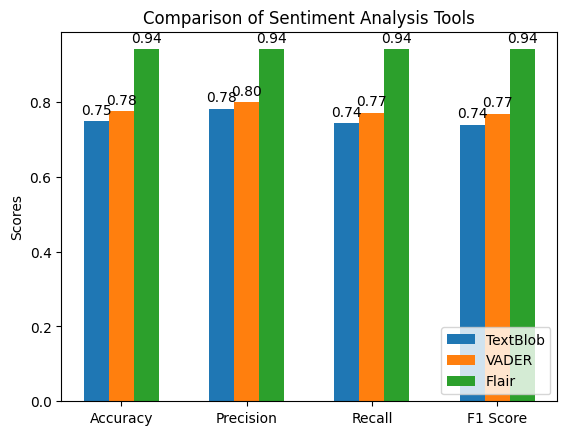

In [66]:
import matplotlib.pyplot as plt

# Conver the results in lists
textblob_values = [accuracy_TextBlob, precision_TextBlob, recall_TextBlob, f1_TextBlob]
# textblobNB_values = [accuracy_TextBlob_NB, precision_TextBlob_NB, recall_TextBlob_NB, f1_TextBlob_NB]
vader_values = [accuracy_VADER, precision_VADER, recall_VADER, f1_VADER]
flair_values = [accuracy_flair, precision_flair, recall_flair, f1_flair]

labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

# Setting the positions and width for the bars
x = range(len(labels))  # the label locations
width = 0.2  # the width of the bars

# Plotting
fig, ax = plt.subplots()
rects1 = ax.bar(x, textblob_values, width, label='TextBlob')
rects2 = ax.bar([p + width for p in x], vader_values, width, label='VADER')
rects3 = ax.bar([p + width * 2 for p in x], flair_values, width, label='Flair')

# Add some text for labels, title, and custom x-axis tick labels
ax.set_ylabel('Scores')
ax.set_title('Comparison of Sentiment Analysis Tools')
ax.set_xticks([p + width for p in x])
ax.set_xticklabels(labels)
ax.legend(loc='lower right')

# Function to add labels on the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

# Attach labels
autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

# Show the plot
plt.show()


# Summary: TextBlob vs. VADER vs. Flair

In this tutorial, we compared TextBlob vs. VADER vs. Flair for sentiment analysis.

* Methodology
 * VADER and TextBlob are lexicon and rule-based.
 * Flair is model-based.
* Meaning of score
 * VADER and TextBlob have sentiment scores ranging from -1 to 1, where -1 means very negative, 1 means very positive, and 0 means neutral.
 * Flair has a score ranging from 0 to 1, where 0 means very unconfident about the prediction and 1 means very confident about the prediction.
* Speed Performance
 * Flair is slower than TextBlob and VADER because the computation algorithm is more complicated.
* Accuracy Performance
 * Based on the results of this project, flair has the best prediction accuracy, VADER is the second-best, and TextBlob is the third.


# References

* [Sentiment Labelled Sentences Data Set on UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Sentiment+Labelled+Sentences)
* [TextBlob Documentation](https://textblob.readthedocs.io/en/dev/)
* [VADER Documentation](https://github.com/cjhutto/vaderSentiment)
* [Flair Documentation](https://github.com/flairNLP/flair)
* [Hutto, C.J. & Gilbert, E.E. (2014). VADER: A Parsimonious Rule-based Model for Sentiment Analysis of Social Media Text. Eighth International Conference on Weblogs and Social Media (ICWSM-14). Ann Arbor, MI, June 2014.](http://comp.social.gatech.edu/papers/icwsm14.vader.hutto.pdf)
